# Confidence Calibration and Error Correlation over Time

This notebook computes and plots the **Expected Calibration Error (ECE)** and the **Pearson correlation between predicted confidence and absolute error** across sequential temporal folds.

It compares:
1. **Non-Wasserstein models** (first row of plots: models without `_wasserstein` in their names).
2. **Wasserstein-regularized models** with intensity 1 (second row of plots: models ending in `_wasserstein` or `_wasserstein-1` with intensity 1).

The data is loaded from the `eval_error_conf-*.csv` files generated during incremental temporal cross-validation.

In [1]:
import os
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use seaborn style for premium aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

## Helper Functions for Calibration Metrics

We implement:
- `expected_calibration_error`: computes the standard ECE on normalized confidence scores.
- `get_ece_and_corr`: loads confidence and prediction error, cleans NaNs, normalizes confidence values to `[0, 1]` where necessary (vital for models whose confidence matches other scales like ratings or log-variances), and returns ECE and correlation.

In [2]:
def expected_calibration_error(confidence, correct, n_bins=10):
    """Compute Expected Calibration Error (ECE) for classification accuracy."""
    confidence = np.asarray(confidence)
    correct = np.asarray(correct)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(confidence)
    for i in range(n_bins):
        mask = (confidence > bin_edges[i]) & (confidence <= bin_edges[i + 1])
        if np.sum(mask) == 0:
            continue
        bin_conf = confidence[mask].mean()
        bin_acc = correct[mask].mean()
        ece += (np.sum(mask) / n) * abs(bin_acc - bin_conf)
    return ece

def get_ece_and_corr(df, threshold=0.5):
    """Extract ECE and Pearson correlation from model run evaluation DataFrame."""
    if "abs_error" in df.columns:
        error = df["abs_error"].values
    else:
        error = np.abs(df["rating"].values - df["r_pred"].values)

    correct = error < threshold
    conf = df["conf_pred"].values

    # Drop NaNs
    valid_mask = ~np.isnan(conf)
    conf = conf[valid_mask]
    correct = correct[valid_mask]
    error = error[valid_mask]

    if len(conf) == 0:
        return np.nan, np.nan

    # Normalize confidence to [0, 1] if values are outside the range
    conf_min = conf.min()
    conf_max = conf.max()
    if conf_max > conf_min:
        if conf_min < 0.0 or conf_max > 1.0:
            conf_scaled = (conf - conf_min) / (conf_max - conf_min)
        else:
            conf_scaled = conf
    else:
        conf_scaled = conf

    ece = expected_calibration_error(conf_scaled, correct)
    corr = np.corrcoef(conf, error)[0, 1]

    return ece, corr

## Load Evaluation Runs and Parse Setup Information

We traverse the `runs` folder, matching runs with their datasets, base models, folds, and Wasserstein regularization settings. We only select Wasserstein intensity 1.0 runs.

In [ ]:
# Resolve directory path
if os.path.exists("runs"):
    runs_dir = "runs"
elif os.path.exists("../runs"):
    runs_dir = "../runs"
else:
    runs_dir = "runs"

datasets_list = ["amazon-beauty", "amazon-movies-tvs", "ml-1m", "netflix-prize"]
pattern_was = re.compile(r"^([a-zA-Z0-9]+)_wasserstein(?:-([0-9.]+))?-([0-9]+)$")
pattern_non = re.compile(r"^([a-zA-Z0-9]+)-([0-9]+)$")

data_points = []

for folder in os.listdir(runs_dir):
    path = os.path.join(runs_dir, folder)
    if not os.path.isdir(path):
        continue
    
    csvs = glob.glob(os.path.join(path, "eval_error_conf-*.csv"))
    if not csvs:
        continue
        
    db = None
    for d in datasets_list:
        if folder.startswith(d + "-"):
            db = d
            break
    if not db:
        continue
        
    rem = folder[len(db)+1:]
    
    # Match Wasserstein runs
    m_was = pattern_was.match(rem)
    if m_was:
        model, intensity, fold = m_was.groups()
        intensity = float(intensity) if intensity is not None else 1.0
        fold = int(fold)
        is_was = True
    else:
        # Match non-Wasserstein runs
        m_non = pattern_non.match(rem)
        if m_non:
            model, fold = m_non.groups()
            intensity = 0.0
            fold = int(fold)
            is_was = False
        else:
            continue
            
    for csv_uri in csvs:
        csv_fold = int(os.path.basename(csv_uri).split("-")[1].split(".")[0])
        try:
            df = pd.read_csv(csv_uri, low_memory=False).dropna()
            ece, corr = get_ece_and_corr(df)
            rmse = np.sqrt(np.mean((df["rating"] - df["r_pred"]) ** 2))
            data_points.append({
                "dataset": db,
                "model": model,
                "is_wasserstein": is_was,
                "intensity": intensity,
                "fold": csv_fold,
                "ece": ece,
                "corr": corr,
                "rmse": rmse
            })
        except Exception as e:
            print(f"Error reading {csv_uri}: {e}")

df_results = pd.DataFrame(data_points)

# Filter out models that do not produce confidence (like standard Matrix Factorization baseline)
# and keep only intensity 1.0 for Wasserstein models
df_filtered = df_results[
    (df_results.model != "mf") &
    ((df_results.is_wasserstein == False) | (df_results.intensity == 1.0))
]

print(f"Loaded {len(df_filtered)} evaluation runs across datasets.")
df_filtered.head()

## Plot Calibration per Time (Fold)

We plot ECE and correlation on a single y-axis (with dynamic limits based on data min/max) with a horizontal line at y=0.0 to clearly separate them and check for consistency or crossing trends.

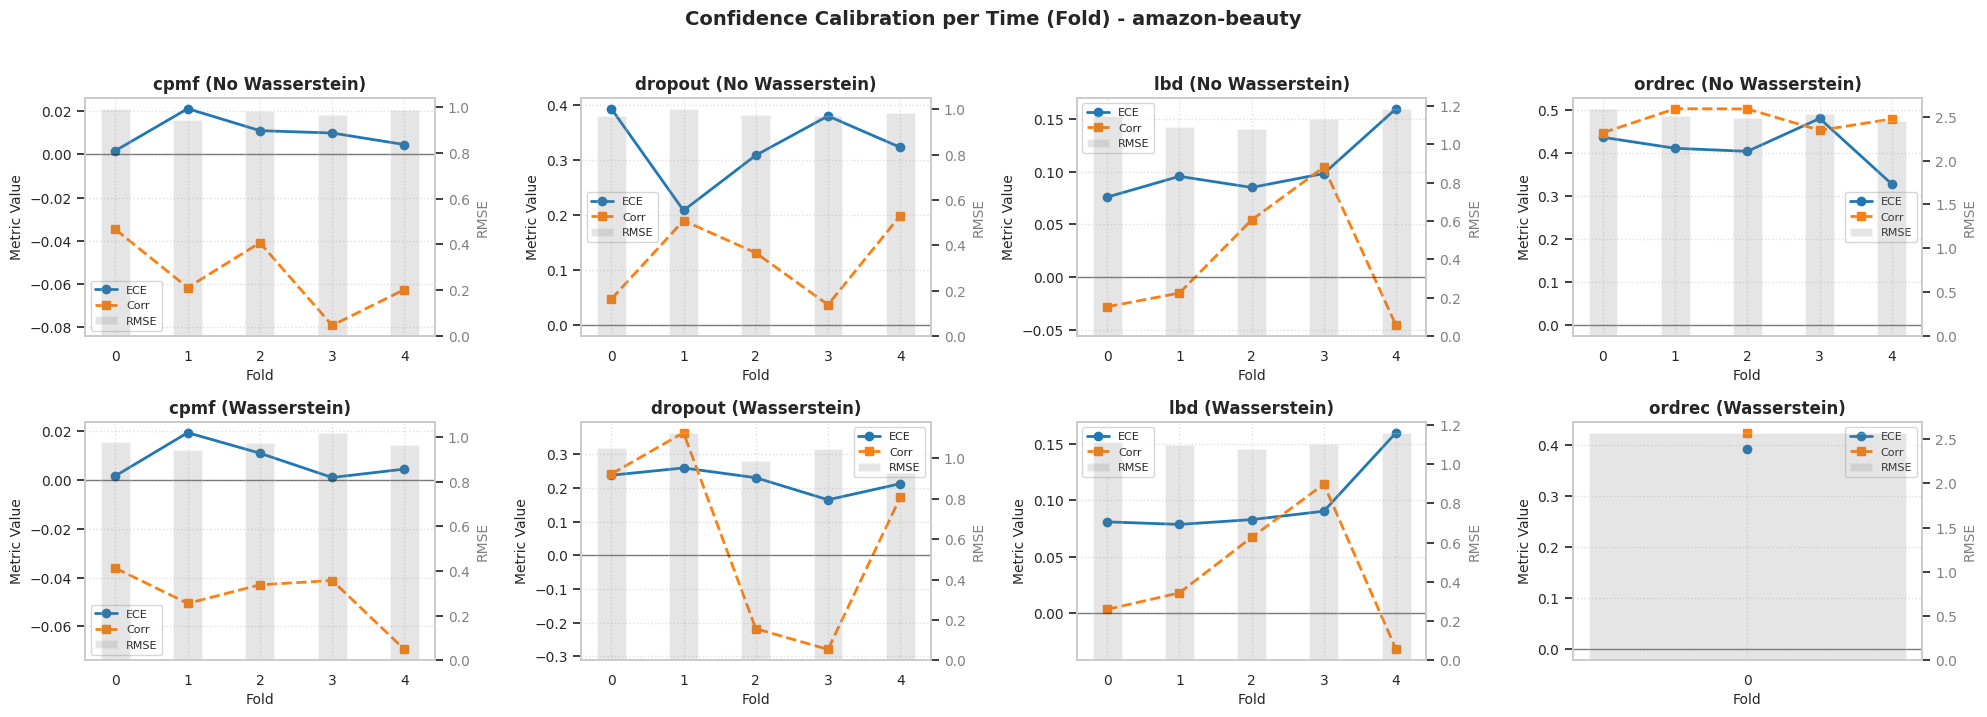

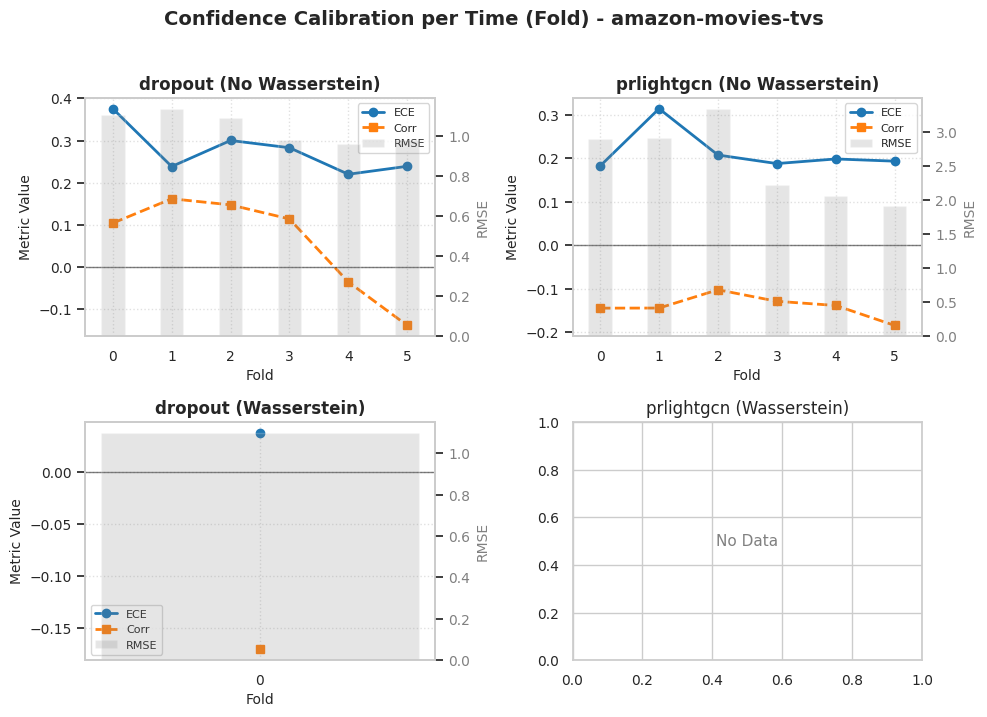

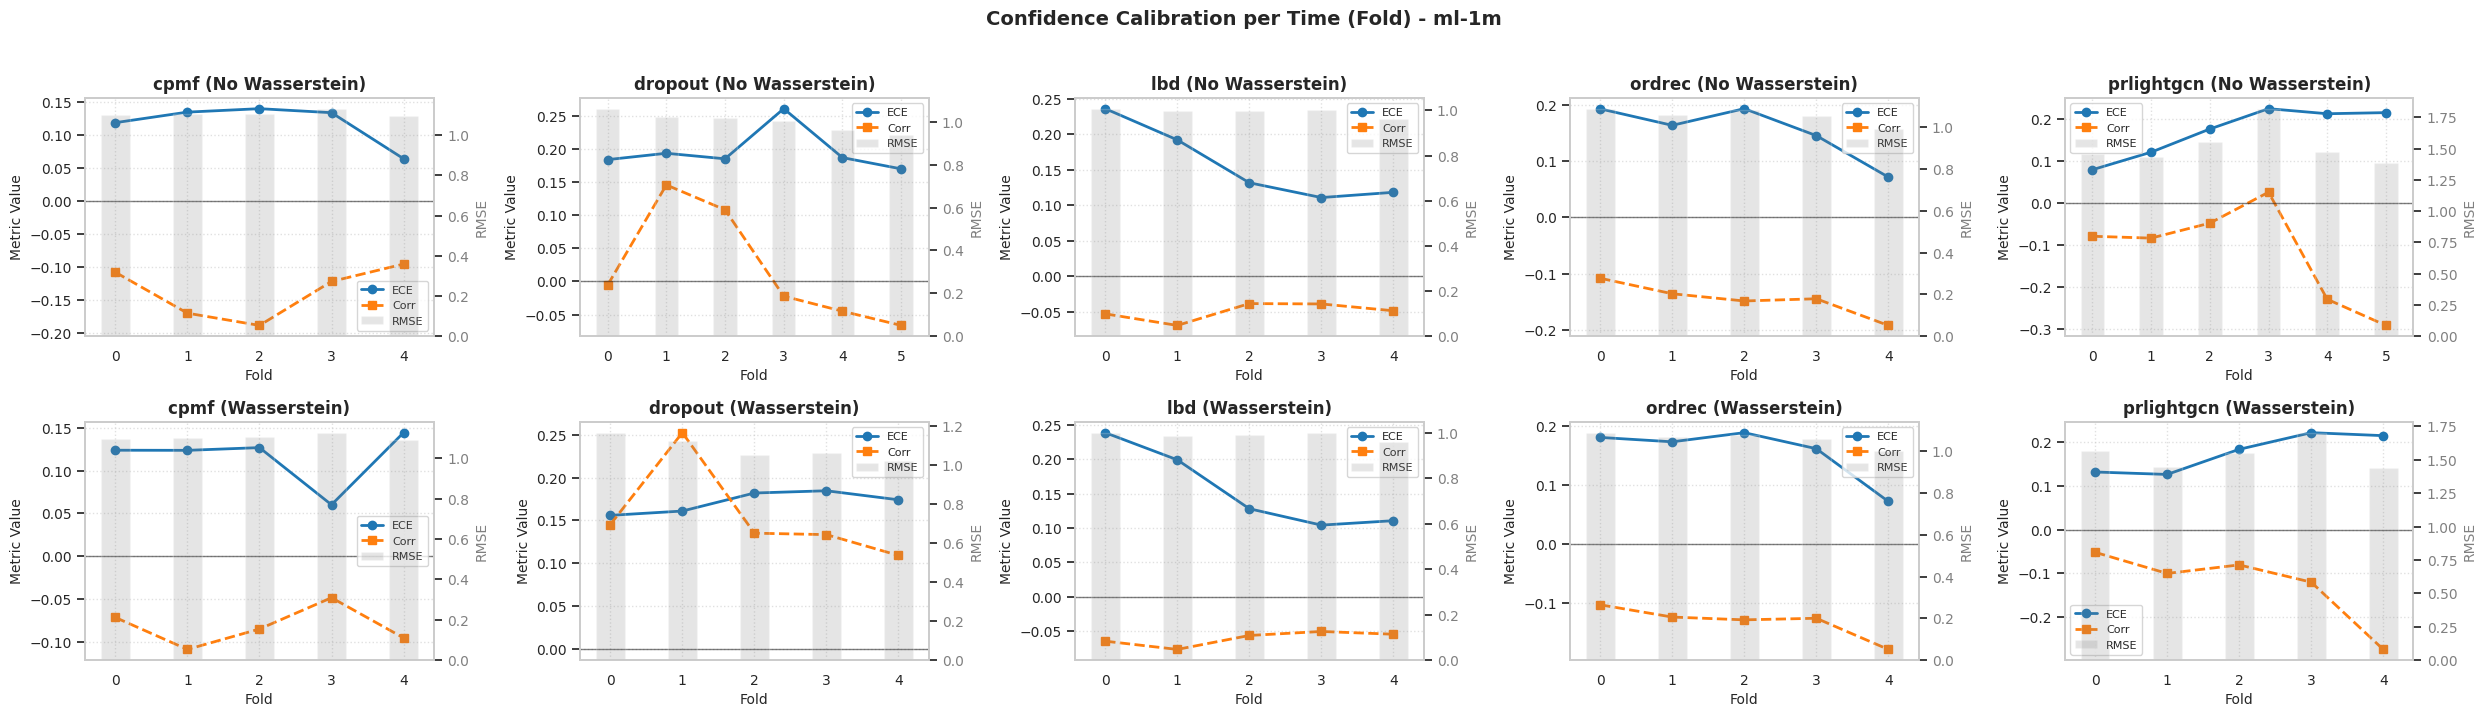

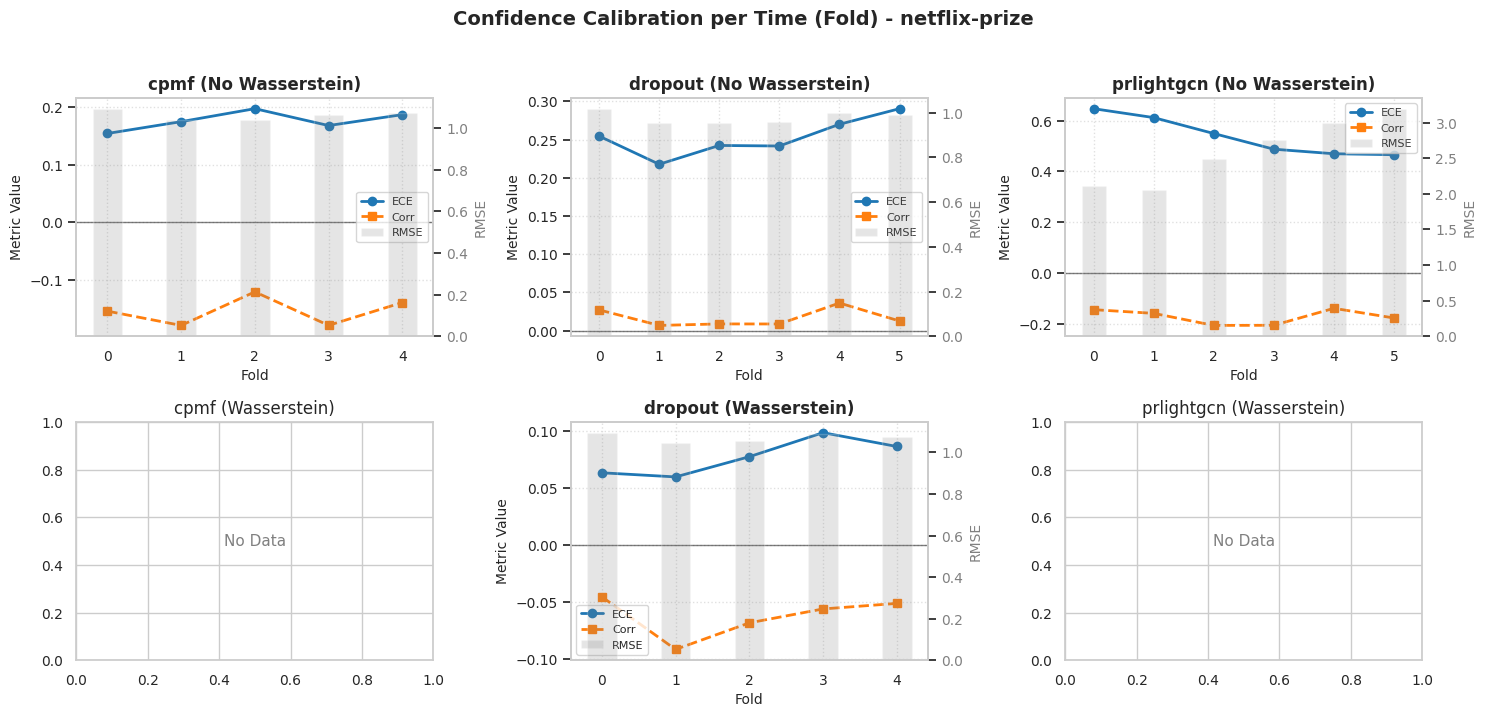

In [ ]:
os.makedirs("plots", exist_ok=True)

for db in sorted(df_filtered["dataset"].unique()):
    df_db = df_filtered[df_filtered["dataset"] == db]
    models = sorted(df_db["model"].unique())
    num_models = len(models)
    
    fig, axes = plt.subplots(2, num_models, figsize=(5 * num_models, 7), sharex=False, squeeze=False)
    
    for col_idx, model in enumerate(models):
        for row_idx, is_was in enumerate([False, True]):
            ax1 = axes[row_idx, col_idx]
            
            # Filter data for this subplot
            df_sub = df_db[(df_db["model"] == model) & (df_db["is_wasserstein"] == is_was)]
            df_sub = df_sub.sort_values("fold")
            
            if df_sub.empty or df_sub["ece"].isna().all():
                ax1.text(0.5, 0.5, "No Data", ha="center", va="center", transform=ax1.transAxes, color="gray")
                ax1.set_title(f"{model} " + ("(Wasserstein)" if is_was else "(No Wasserstein)"), fontsize=12)
                continue
                
            folds = df_sub["fold"].values
            ece_vals = df_sub["ece"].values
            corr_vals = df_sub["corr"].values
            rmse_vals = df_sub["rmse"].values
            
            # Plot ECE and Correlation on the same axis (ax1)
            ax1.plot(folds, ece_vals, color="#1f77b4", marker="o", label="ECE", linewidth=2)
            ax1.plot(folds, corr_vals, color="#ff7f0e", marker="s", linestyle="--", label="Corr", linewidth=2)
            
            # Plot a baseline at y=0
            ax1.axhline(0, color="black", linewidth=1, linestyle="-", alpha=0.5)
            
            # Titles and tick configuration
            ax1.set_title(f"{model} " + ("(Wasserstein)" if is_was else "(No Wasserstein)"), fontsize=12, fontweight="bold")
            ax1.set_xlabel("Fold", fontsize=10)
            ax1.set_xticks(folds)
            ax1.set_ylabel("Metric Value", fontsize=10)
            
            # Styling grid
            ax1.grid(True, linestyle=":", alpha=0.6)
            
            # Create a secondary y-axis for the RMSE bar chart on the right side
            ax2 = ax1.twinx()
            ax2.bar(folds, rmse_vals, color="gray", alpha=0.2, width=0.4, label="RMSE")
            ax2.set_ylabel("RMSE", color="gray", fontsize=10)
            ax2.tick_params(axis='y', labelcolor="gray")
            ax2.grid(False)
            
            # Combine legends from both axes
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=8)
            
    #plt.suptitle(f"Confidence Calibration per Time (Fold) - {db}", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plot_path = f"plots/calibration_time_{db}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()